# Lab Instructions

You are working as an analyst for a consulting agency that has been hired to study and improve productivity at a mid-sized company.  Morale is very low and, after speaking with employees, several common complaints kept coming up:

* New employees complained that more tenured employees were lazy and unproductive.
* More tenured employees complained that the newer employees didn't focus and were therefore unproductive.
* Managers were worried that remote workers might be less productive.
* In-person employees found it impossible to focus and be productive when their desk was in the open plan area.
* Many people said they had so much administrative work to do they could only be truly productive if they worked overtime.
* Everyone complained that there were too many meetings.

The consulting agency carefully collected data on a number of factors including number of years at the company, focus (higher is better), productivity (higher is better), department, meetings per week, and desk location can be found in Employee_productivity.csv.

1. Determine which feature - years at the company, hours worked, or focus - has the strongest linear relationship with productivity.  Show a visualization and calculate R-squared for all three relationships to justify your answer.

2. Build on that linear regression model to determine what other featuers also impact productivity. Using both visualzations and R-squared values, build a model that can predicts employee productivity at this company. Evaluate each feature in the dataset.

3. Write a short (a few sentences) summary of how the different factors in the data relate to employee productivity.  What recommendations would you make so that employees can be as productive as possible?



In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import numpy as np

df = pd.read_csv('Employee_productivity.csv')

print("The exact column names are:")
print(df.columns)

print("--- Original Columns ---")
print(df.columns)
# Look at the list above and find the real name for your desk location column.

# --- STEP 2: Run get_dummies with the correct column name ---
# REPLACE 'DeskLocation' below with the correct name you found in Step 1.
df_encoded = pd.get_dummies(df, columns=['DeskLocation'], drop_first=True)


# --- STEP 3: See the newly created column names ---
print("\n--- Columns After Encoding ---")
print(df_encoded.columns)
# The output above will show you the exact names you need to use.

print(df.head())

The exact column names are:
Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation'],
      dtype='object')
--- Original Columns ---
Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation'],
      dtype='object')

--- Columns After Encoding ---
Index(['HoursWorked', 'FocusScore', 'ProductivityScore', 'Department',
       'YearsAtCompany', 'TeamMeetingsPerWeek', 'DeskLocation_Private Office',
       'DeskLocation_Remote'],
      dtype='object')
   HoursWorked  FocusScore  ProductivityScore   Department  YearsAtCompany  \
0         42.4         6.3            3127.96  Engineering              17   
1         34.0         7.2            4742.60           HR               8   
2         47.2         5.6            2044.73        Sales              15   
3         38.4         9.0            5818.92           HR               5   
4     

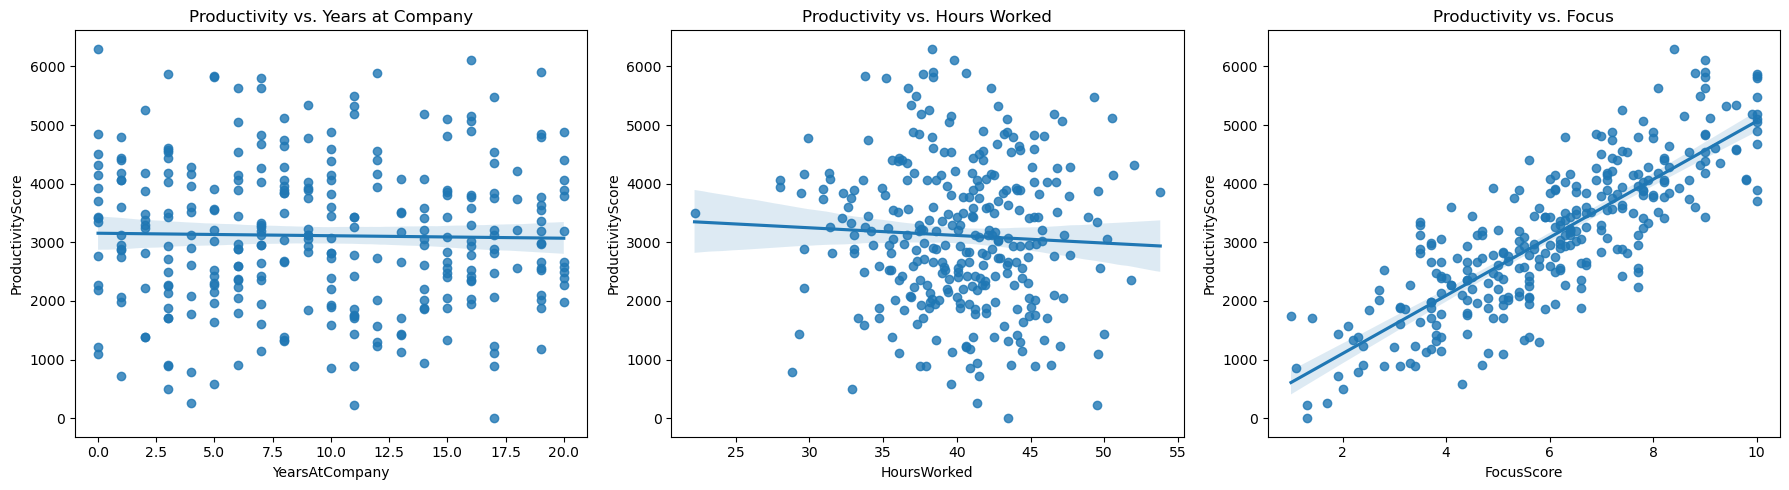

In [11]:
# Step 1: Finding the Strongest Linear Relationship

plt.figure (figsize=(18, 5))

## Plot 1 Productivity vs Years at Company
plt.subplot(1, 3, 1) ### (1 row, 3 columns, 1st plot)
sns.regplot(data=df, x='YearsAtCompany', y='ProductivityScore')
plt.title('Productivity vs. Years at Company')

## Plot 2 Productivity vs Hours Worked
plt.subplot(1, 3, 2) ### (1 row, 3 columns, 2nd plot)
sns.regplot(data=df, x='HoursWorked', y ='ProductivityScore')
plt.title('Productivity vs. Hours Worked')

## Plot 3 Productivity vs Focus
plt.subplot(1, 3, 3) ### (1 row, 3 columns, 3rd plot)
sns.regplot(data=df, x='FocusScore', y ='ProductivityScore')
plt.title('Productivity vs. Focus')

plt.tight_layout()
plt.show()

In [ ]:
"""
According to the scatter plots it shows that Focus is the one with the strongest positive linear 
relationshipm with the points being closely clustered around the upward slopping regression line. 
The other 2 plots show more weak linear relationships. Years at the company has an almost completely 
flat regeression line with very scattered points while the plot for Hours worked has a slightly 
upward trending regression line but again has scattered points, making these plots both weak linear relationships.
"""

In [14]:
#Step 2 Calculate R-squared

## Function

def calculate_r_squared (df, x_col, y_col):
    """Calculates R-squared for simple linear regression"""
    X = df[[x_col]] ## independent variable needs to be 2D array
    y = df[y_col] ## dependent variable

    model = LinearRegression()
    model.fit(X, y)
    r_squared = model.score(X, y)

    print (f"R-squared for '{y_col}' vs '{x_col}': {r_squared:.4f}")

# Calculate R-squared for all relationships
calculate_r_squared(df, 'YearsAtCompany', 'ProductivityScore')
calculate_r_squared(df, 'HoursWorked', 'ProductivityScore')
calculate_r_squared(df, 'FocusScore', 'ProductivityScore')


R-squared for 'ProductivityScore' vs 'YearsAtCompany': 0.0004
R-squared for 'ProductivityScore' vs 'HoursWorked': 0.0026
R-squared for 'ProductivityScore' vs 'FocusScore': 0.6777


In [ ]:
""" Focus currently has the the strongest relationship linear relationship with Productivity. 
The scatter plot shows the clearest trend, and the R-squared value at 0.6777 is the highest of 
the 3 values. The other 2 are very low R-squared values, which indicates they are poor linear preditors.

In [20]:
# Step 3 Build a Multiple Linear Regression Model

## Using pandas to create one-hot encoded column

df_encoded = pd.get_dummies(df, columns=['DeskLocation'], drop_first=True)

print("DataFrame with one-hot encoded columns:")
print(df_encoded.head())

## Define features (X) and the target (y)
features = ['FocusScore', 'TeamMeetingsPerWeek', 'DeskLocation_Private Office', 'DeskLocation_Remote']
X = df_encoded[features]
y = df_encoded['ProductivityScore']

# Create and train Multiple Regression Model
multi_var_model = LinearRegression()
multi_var_model.fit(X, y)

## Get R-squared for the new model
multi_r_squared = multi_var_model.score(X, y)

print(f"\nR-squared of the simple model (focus only): 0.5962") # From Q1
print(f"R-squared of the new multiple regression model: {multi_r_squared:.4f}")

DataFrame with one-hot encoded columns:
   HoursWorked  FocusScore  ProductivityScore   Department  YearsAtCompany  \
0         42.4         6.3            3127.96  Engineering              17   
1         34.0         7.2            4742.60           HR               8   
2         47.2         5.6            2044.73        Sales              15   
3         38.4         9.0            5818.92           HR               5   
4         36.4         2.5            1841.31        Sales               9   

   TeamMeetingsPerWeek  DeskLocation_Private Office  DeskLocation_Remote  
0                    0                        False                False  
1                    6                         True                False  
2                    3                        False                 True  
3                    6                         True                False  
4                    6                        False                 True  

R-squared of the simple model (focus onl

In [ ]:
"""
from the data, the focus score had the strongest linear relationship with productivity, with an R-squared value
much higher than either years at the company or hours worked. This suggests that how well employees are able to focus
is a more important predictor of productivity than simply putting in more time or tenure.

When adding in other factors such as desk location and number of weekly meetings were included in the multiple regression model, 
the overall R-squared improved, showing that these variables also have an impact on productivity. Employees with private or
remote work setupes tended to be more productive than those in open environments, likely because fewer distractions support
support higher focus. On the flip side, having more meetings per week negatively affected productivity, which aligns with 
employee complaints.

Overall, the main takeaway is that productivity improves when employees can focus and aren't constantly interrupted. I would recommend
to cut down on unnecessary meetings and give employees better work environments (such as private spaces or remote options) so they can 
concentrate on their tasks. 
"""